# Make WO gifs

## Import stuff

In [1]:
import datacube
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
import xarray as xr
import os
import seaborn as sns

import glob
import imageio
import numpy as np
from PIL import Image

from odc.ui import with_ui_cbk
from datacube.utils.cog import write_cog


import sys
sys.path.insert(1, "../Tools/")
from dea_tools.plotting import rgb, display_map

## Set up functions

In [2]:
def make_gif(frame_folder, start_year, end_year, location):
    """
    Create a gif from a folder of images (png). 
    Parameters:
    - frame folder (str): path to the folder containing the images. 
    - start_year (int): starting year for the GIF title.
    - end_year (int): ending year for the GIF title.
    - location (str): location for the GIF title.
    Returns:
    - the gif will be saved in the current folder. 
    """
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.png"))]
    frame_one = frames[0]
    frame_one.save(f"Geomedian and WO {start_year}-{end_year} {location}.gif", format="GIF", append_images=frames,
               save_all=True, duration=500, loop=0, optimize=False)
    print("Finished ( ͡° ͜ʖ ͡° )")

In [3]:
def load_wo_data(product, measurements, lon_range, lat_range, year):
    """
    Load wo dataset for a given year.

    Parameters:
    - product (str): product name.
    - measurements (list): list of measurement names.
    - lon_range (tuple): longitude range.
    - lat_range (tuple): latitude range.
    - year (int): year for which data is to be loaded.

    Returns:
    - geomedian (xarray.Dataset): Loaded geomedian dataset.
    """
    dc = datacube.Datacube(app="")
    wo = dc.load(
        product=product,
        measurements=measurements,
        x=lon_range,
        y=lat_range,
        time=(str(year), str(year)),
    )
    return wo

In [4]:
def get_product_for_year(year):
    """
    Get the product name based on the given year.

    Parameters:
    - year (int): year for which product is needed.

    Returns:
    - product (str): product name.
    """
    if 1988 <= year <= 1999:
        return "ga_ls5t_gm_cyear_3"
    elif 2000 <= year <= 2003:
        return "ga_ls7e_gm_cyear_3"
    elif 2004 <= year <= 2007:
        return "ga_ls5t_gm_cyear_3"
    elif year == 2008:
        return "ga_ls7e_gm_cyear_3"
    elif 2009 <= year <= 2011:
        return "ga_ls5t_gm_cyear_3"
    elif year == 2012:
        return "ga_ls7e_gm_cyear_3"
    elif year >= 2013:
        return "ga_ls8cls9c_gm_cyear_3"
    else:
        return None

In [5]:
def load_geomedian_data(product, measurements, lon_range, lat_range, year):
    """
    Load geomedian dataset for a given year.

    Parameters:
    - product (str): product name.
    - measurements (list): list of measurement names.
    - lon_range (tuple): longitude range.
    - lat_range (tuple): latitude range.
    - year (int): year for which data is to be loaded.

    Returns:
    - geomedian (xarray.Dataset): Loaded geomedian dataset.
    """
    dc = datacube.Datacube(app="")
    geomedian = dc.load(
        product=product,
        measurements=measurements,
        x=lon_range,
        y=lat_range,
        time=(str(year), str(year)),
    )
    return geomedian

In [6]:
def delete_generated_images(folder):
    """
    Delete all the images from the 'images' directory.

    Parameters:
    - folder (str): name of folder/folder path

    Returns:
    - None
    """
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        try:
            if os.path.isfile(file_path):
                os.unlink(file_path)
        except Exception as e:
            print(f"Error deleting file {file_path}: {e}")

In [7]:
def plot_image(gm, wo, year, location, alpha):
    # f, ax = plt.subplots(figsize=(5, 6), tight_layout=True)
    # f, ax = plt.subplots(figsize=(3, 17), tight_layout=True)
    f, ax = plt.subplots(tight_layout=True)

    p = wo.plot(cmap=custom_cmap, ax=ax)  
    rgb(gm, bands=["nbart_red", "nbart_green", "nbart_blue"], ax=ax, alpha=alpha)

    year_text = f'{year}'

    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

    p.colorbar.remove()
    
    ax.text(0.95, 0.95, year_text, transform=ax.transAxes, fontsize=12,
            ha='right', va='top', color='white', bbox=dict(facecolor='black', edgecolor='black'))
    
    # use this if you are using the rotated gif
    # ax.text(0.07, 0.97, year_text, transform=ax.transAxes, fontsize=12,
    #     ha='right', va='top', color='white', bbox=dict(facecolor='black', edgecolor='black'), rotation=90) #0.15,0.95 for long
    
    plt.savefig(f'images/{year}_{location}.png', dpi=150, bbox_inches='tight', pad_inches=0.0)  
    plt.close() 

In [8]:
def plot_image_cbar(gm, wo, year, location, alpha):
    f, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
    # f, ax = plt.subplots(figsize=(3, 17), tight_layout=True)
    # f, ax = plt.subplots(tight_layout=True)

    p = wo.plot(cmap=custom_cmap, ax=ax, vmin=0, vmax=100)  
    rgb(gm, bands=["nbart_red", "nbart_green", "nbart_blue"], ax=ax, alpha=alpha)

    year_text = f'{year}'

    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

    p.colorbar.remove()
    # f.colorbar(p, orientation='horizontal', pad=0.002).set_label('Water Summary (%)')
    cbar = f.colorbar(p, orientation='vertical', pad=0.02)
    cbar.set_label('Water Summary (%)')
    cbar.set_ticks([0, 20, 40, 60, 80, 100])
    cbar.ax.tick_params(size=0)
    
    ax.text(0.10, 0.95, year_text, transform=ax.transAxes, fontsize=12,
            ha='right', va='top', color='white', bbox=dict(facecolor='black', edgecolor='black'))
    
    # use this if you are using the rotated gif
    # ax.text(0.07, 0.97, year_text, transform=ax.transAxes, fontsize=12,
    #     ha='right', va='top', color='white', bbox=dict(facecolor='black', edgecolor='black'), rotation=90) #0.15,0.95 for long
    
    plt.savefig(f'images/{year}_{location}.png', dpi=150, bbox_inches='tight', pad_inches=0.0)  
    plt.close() 

In [9]:
def generate_all_plots(start_year, end_year, alpha):
    for year in range(start_year, end_year + 1):
        
        # load gm
        product = get_product_for_year(year)
        year = str(year)
        gm = load_geomedian_data(product=product, 
                                 measurements=["nbart_red", "nbart_green", "nbart_blue"], 
                                 lon_range=lon_range, 
                                 lat_range=lat_range, 
                                 year=year)
        # load wo
        wo = load_wo_data("ga_ls_wo_fq_cyear_3", 
                  measurements = ["frequency"], 
                  lon_range=lon_range, 
                  lat_range=lat_range, 
                  year = year)
        # turn 0s into nan so they plot transparent 
        # nan_wo = wo.frequency.where(wo.frequency != 0)
        wp100 = wo.frequency * 100
        nan_wo = wp100.where(wo.frequency != 0)
        nan_wo = nan_wo.where(nan_wo >= 2, np.nan)

        # plot it
        # plot_image(gm, nan_wo, year, location, alpha)
        plot_image_cbar(gm, nan_wo, year, location, alpha)

In [10]:
# mako_colormap = sns.color_palette("mako_r", as_cmap=True)
# mako_colormap

# https://github.com/GeoscienceAustralia/dea-config/blob/a7a704f69475fbe46c1c3f09ff75496dd9f6759e/prod/services/wms/ows_refactored/inland_water/wofs/styles_wo_cfg.py
# color_ramp = [
#     {"value": 0.0, "color": "#FFFFFF", "alpha": 0.0},
#         {"value": 0.02, "color": "#FFFFFF", "alpha": 0.0},
#         {"value": 0.05, "color": '#aee3c0', "alpha": 0.25},
#         {"value": 0.1, "color": '#6dd3ad', "alpha": 0.75},
#         {"value": 0.2, "color": '#44bcad', "alpha": 1.0},
#         {"value": 0.3, "color": '#35a1ab', "alpha": 1.0},
#         {"value": 0.4, "color": '#3487a6', "alpha": 1.0},
#         {"value": 0.5, "color": '#366da0', "alpha": 1.0},
#         {"value": 0.6, "color": '#3d5296', "alpha": 1.0},
#         {"value": 0.7, "color": '#403974', "alpha": 1.0},
#         {"value": 0.8, "color": '#35264c', "alpha": 1.0},
#         {"value": 0.9, "color": '#231526', "alpha": 1.0},
# ]

# values = [entry["value"] for entry in color_ramp]
# colors = [entry["color"] for entry in color_ramp]
# alphas = [entry["alpha"] for entry in color_ramp]

# # Create the custom colormap with specified colors and alpha values
# color_list = []
# for color, alpha in zip(colors, alphas):
#     rgba = mcolors.hex2color(color) + (alpha,)  # Convert hexadecimal color to RGBA tuple
#     color_list.append(rgba)

# custom_cmap = mcolors.ListedColormap(color_list)

In [11]:
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import numpy as np

# # Define the color ramp with data mapping points from 0.0 to 1.0
# color_ramp = [
#     {"value": 0.0, "color": "#FFFFFF", "alpha": 0.0},
#     {"value": 0.02, "color": "#FFFFFF", "alpha": 0.0},
#     {"value": 0.05, "color": '#aee3c0', "alpha": 0.25},
#     {"value": 0.1, "color": '#6dd3ad', "alpha": 0.75},
#     {"value": 0.2, "color": '#44bcad', "alpha": 1.0},
#     {"value": 0.3, "color": '#35a1ab', "alpha": 1.0},
#     {"value": 0.4, "color": '#3487a6', "alpha": 1.0},
#     {"value": 0.5, "color": '#366da0', "alpha": 1.0},
#     {"value": 0.6, "color": '#3d5296', "alpha": 1.0},
#     {"value": 0.7, "color": '#403974', "alpha": 1.0},
#     {"value": 0.8, "color": '#35264c', "alpha": 1.0},
#     {"value": 0.9, "color": '#231526', "alpha": 1.0},
#     {"value": 1.0, "color": '#231526', "alpha": 1.0}
# ]


# # Define custom colormap based on the adjusted color ramp
# color_stops = [(entry['value'], entry['color']) for entry in color_ramp]
# custom_cmap = colors.LinearSegmentedColormap.from_list('custom_colormap', color_stops)
# custom_cmap

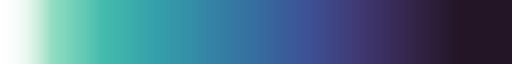

In [12]:
import matplotlib.colors as colors

# Define the color ramp with data mapping points from 0.0 to 1.0
color_ramp = [
    {"value": 0.0, "color": "#FFFFFF", "alpha": 0.0},
    {"value": 0.05, "color": '#aee3c0', "alpha": 0.25},
    {"value": 0.1, "color": '#6dd3ad', "alpha": 0.75},
    {"value": 0.2, "color": '#44bcad', "alpha": 1.0},
    {"value": 0.3, "color": '#35a1ab', "alpha": 1.0},
    {"value": 0.4, "color": '#3487a6', "alpha": 1.0},
    {"value": 0.5, "color": '#366da0', "alpha": 1.0},
    {"value": 0.6, "color": '#3d5296', "alpha": 1.0},
    {"value": 0.7, "color": '#403974', "alpha": 1.0},
    {"value": 0.8, "color": '#35264c', "alpha": 1.0},
    {"value": 0.9, "color": '#231526', "alpha": 1.0},
    {"value": 1.0, "color": '#231526', "alpha": 1.0}
]

# Ensure the color ramp starts at 0.0 and ends at 1.0
if color_ramp[0]['value'] != 0.0:
    color_ramp.insert(0, {"value": 0.0, "color": color_ramp[0]['color'], "alpha": color_ramp[0]['alpha']})

if color_ramp[-1]['value'] != 1.0:
    color_ramp.append({"value": 1.0, "color": color_ramp[-1]['color'], "alpha": color_ramp[-1]['alpha']})

# Create color stops based on the adjusted color ramp with alpha values
color_stops = []
for entry in color_ramp:
    color_with_alpha = (entry['color'], entry['alpha'])
    color_stops.append((entry['value'], color_with_alpha))

# Create the custom colormap
custom_cmap = colors.LinearSegmentedColormap.from_list('custom_colormap', color_stops)

# Optionally set over/under values for the colormap
# custom_cmap.set_over(color_ramp[-1]['color'], alpha=color_ramp[-1]['alpha'])
# custom_cmap.set_under(color_ramp[0]['color'], alpha=color_ramp[0]['alpha'])
custom_cmap

## Set up location

In [51]:
# location = "Lake Victoria, Vic"
# lat =-34.0731
# lon = 141.3020
# lat_buffer = 0.26
# lon_buffer = 0.4

# location = "Espernce, WA"
# lat =-33.2995
# lon = 122.2078
# lat_buffer = 0.13
# lon_buffer = 0.2
# lat_buffer = 0.1
# lon_buffer = 0.2

# location = "Lake Ballard, WA"
# lat = -29.4635
# lon = 120.8743
# lat_buffer = 0.26
# lon_buffer = 0.4

location = "Jebarjup, WA"
lat = -34.2393
lon = 117.7563
lat_buffer = 0.13
lon_buffer = 0.2
# lat_buffer = 0.05
# lon_buffer = 0.4

# location = "Lake Dundas, WA"
# lat = -32.5705
# lon = 121.8391
# lat_buffer = 0.26
# lon_buffer = 0.4

# location = "Burketown, Qld"
# lat =-17.4958
# lon =  139.5212
# lat_buffer = 0.2
# lon_buffer = 0.3

# location = "Borroloola, NT"
# lat =-15.9410
# lon = 136.7097
# lat_buffer = 0.13
# lon_buffer = 0.2


# location = "Lake George, NSW"
# lat = -35.0991
# lon =  149.4278
# lat_buffer = 0.13
# lon_buffer = 0.2

#=====================================================
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

display_map(x=lon_range, y=lat_range)

## Make gifs

In [41]:
# year = "2015"

# # check the area looks alright
# gm = load_geomedian_data(product="ga_ls8cls9c_gm_cyear_3", 
#                                  measurements=["nbart_red", "nbart_green", "nbart_blue"], 
#                                  lon_range=lon_range, 
#                                  lat_range=lat_range, 
#                                  year=year)
# wo = load_wo_data("ga_ls_wo_fq_cyear_3", 
#                   measurements = ["frequency"], 
#                   lon_range=lon_range, 
#                   lat_range=lat_range, 
#                   year = year)
# nan_wo = wo.frequency.where(wo.frequency != 0)
# # rgb(gm)
# wp100 = wo.frequency * 100
# nan_wo = wp100.where(wo.frequency != 0)
# plot_image_cbar(gm, nan_wo, year, location, 1)

In [47]:
start_year = 1988
end_year = 2023

In [52]:
generate_all_plots(start_year, end_year, 1)

In [53]:
make_gif("images", start_year, end_year, location)
# make_gif("rotated_images", start_year, end_year, location)

Finished ( ͡° ͜ʖ ͡° )


In [54]:
delete_generated_images("images")
delete_generated_images("rotated_images")

In [74]:
input_folder = "images"
output_folder = "rotated_images"
rotate_images(input_folder, output_folder)

Rotation complete!


In [73]:
from PIL import Image
import os

def rotate_images(input_folder, output_folder):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # List all files in the input folder
    files = os.listdir(input_folder)

    # Process each file in the input folder
    for file in files:
        # Check if the file is an image (you can add more image file extensions if needed)
        if file.endswith(".jpg") or file.endswith(".jpeg") or file.endswith(".png"):
            # Open the image file
            with Image.open(os.path.join(input_folder, file)) as img:
                # Rotate the image 90 degrees to the right
                rotated_img = img.transpose(Image.ROTATE_270)
                
                # Save the rotated image to the output folder
                rotated_img.save(os.path.join(output_folder, file))

    print("Rotation complete!")
